In [1]:
import scanpy as sc 
import metashells as ms
import anndata as ad

In [10]:
# ---------------------------------------------------------------------------
# Canonical condition × sex palette for ALL non-UMAP analysis plots.
# Edit here once and every Sankey / chord / heatmap downstream picks it up.
# UMAPs are explicitly excluded (scanpy palettes drive those).
# ---------------------------------------------------------------------------
SEX_CONDITION_PALETTE = {
    ('M', 'WT'): '#004a99',  # Control male
    ('M', 'KO'): '#90bff9',  # SkM-KO male
    ('F', 'WT'): '#f71480',  # Control female
    ('F', 'KO'): '#fa98c7',  # SkM-KO female
}

# Sex-only collapse (used when a plot isn't split by condition — picks WT shade).
SEX_PALETTE = {
    'F': SEX_CONDITION_PALETTE[('F', 'WT')],
    'M': SEX_CONDITION_PALETTE[('M', 'WT')],
}

# Make sure SVG text stays editable in Illustrator (text elements, not paths).
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": "none",
})
figure_params = {
    "dpi": 300,
    "bbox_inches": "tight",
    "format": "svg",
    "transparent": True,
}

figures_dir = '/ix/djishnu/Akanksha/datasets/ERCC1_KO/figures'

In [7]:
# adata_with_labels_file = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/scANVI_v3.h5ad'
# adata = sc.read_h5ad(adata_with_labels_file)

In [3]:
adata

AnnData object with n_obs × n_vars = 87916 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_type_colo

In [4]:
adata.X = adata.layers['counts']
adata.X.min(), adata.X.max()

(np.float64(0.0), np.float64(2359.0))

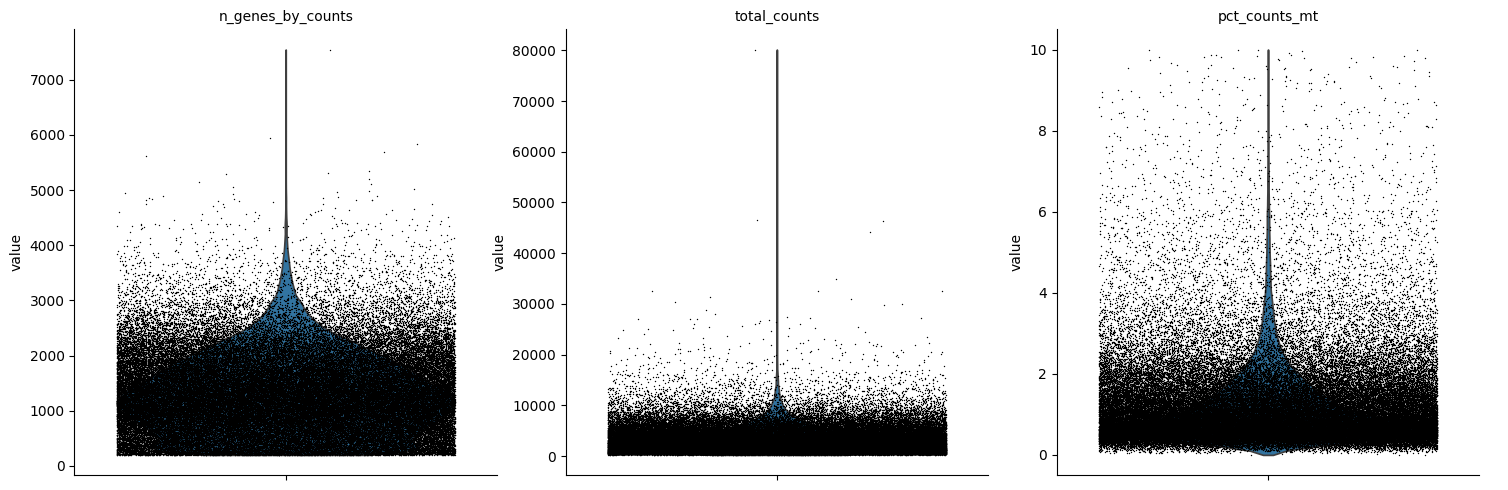

In [5]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


In [6]:
# Filter out cells with high mitochondrial gene percentage
adata = adata[adata.obs['pct_counts_mt'] < 5]
adata

View of AnnData object with n_obs × n_vars = 86672 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid', '_scvi_uuid', 'batch_colors', 'cell_t

### Pre-proc data

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

/ocean/projects/cis240075p/asachan/.conda/envs/metasheller-py311/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/ocean/projects/cis240075p/asachan/.conda/envs/metasheller-py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
adata.X.min(), adata.X.max()

(np.float64(0.0), np.float64(8.653730285872221))

In [9]:
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, use_rep='X_pca', n_pcs=30)

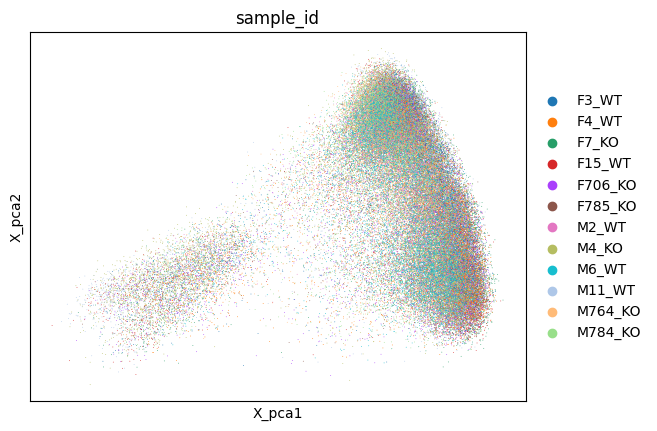

In [10]:
sc.pl.embedding(adata, basis='X_pca', color=['sample_id'])

In [11]:
sc.tl.umap(adata)

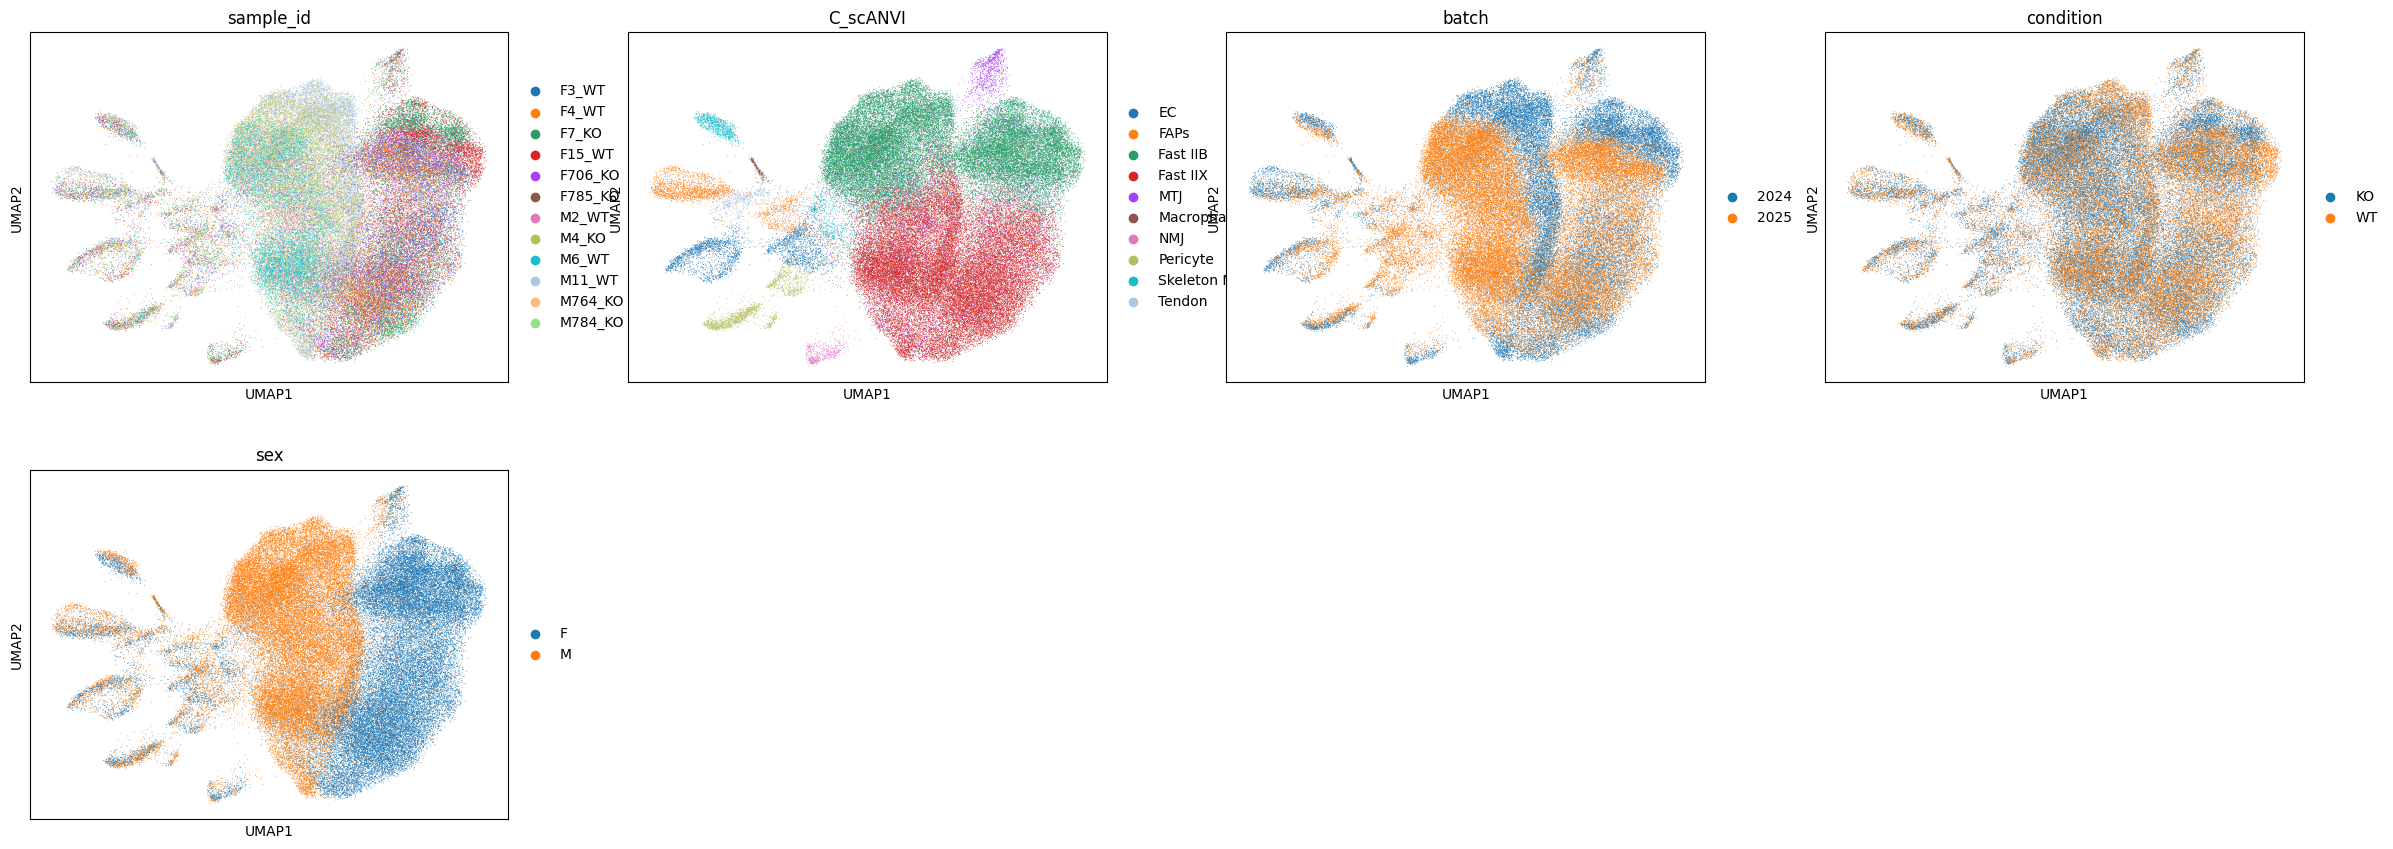

In [12]:
sc.pl.umap(adata, color=['sample_id', 'C_scANVI', 'batch', 'condition', 'sex'])

# Harmony to correct for batch effect

In [13]:
# Stronger correction with optimized parameters
sc.external.pp.harmony_integrate(
    adata, 
    key='batch',
    theta=4,        # Increase from default (2) for stronger correction
    lamb=1,         # Add regularization
    sigma=0.1,      # Decrease bandwidth
    max_iter_harmony=100,  # More iterations
    random_state=42
)

2026-01-13 18:49:27,371 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-01-13 18:49:33,409 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-01-13 18:49:33,880 - harmonypy - INFO - Iteration 1 of 100
2026-01-13 18:49:56,732 - harmonypy - INFO - Iteration 2 of 100
2026-01-13 18:50:18,572 - harmonypy - INFO - Iteration 3 of 100
2026-01-13 18:50:29,706 - harmonypy - INFO - Iteration 4 of 100
2026-01-13 18:50:39,698 - harmonypy - INFO - Iteration 5 of 100
2026-01-13 18:50:48,612 - harmonypy - INFO - Iteration 6 of 100
2026-01-13 18:51:03,107 - harmonypy - INFO - Converged after 6 iterations


In [14]:
sc.pp.neighbors(adata, use_rep='X_pca_harmony', n_pcs=30)
sc.tl.umap(adata)

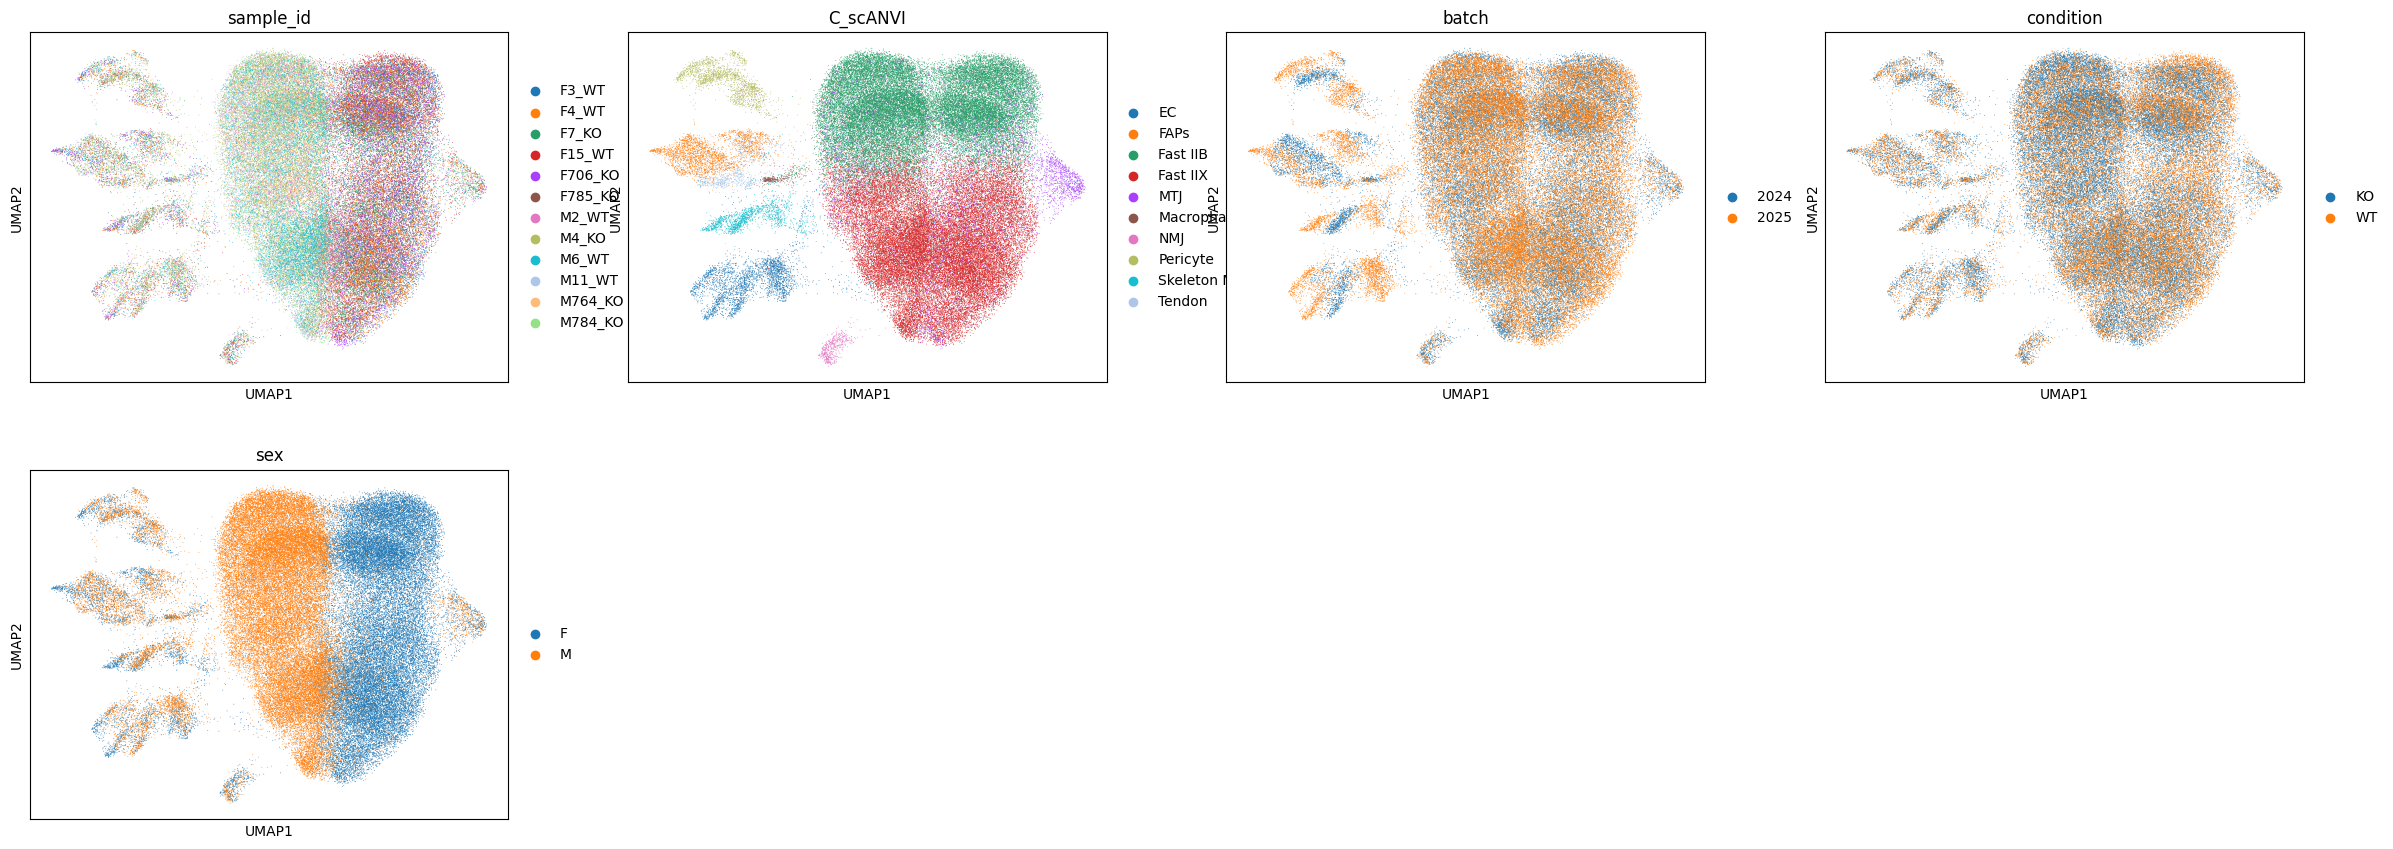

In [15]:
sc.pl.umap(adata, color=['sample_id', 'C_scANVI', 'batch', 'condition', 'sex'])

In [ ]:
# save the adata object
adata.write_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_harmony_v2.h5ad')

### Save the adata files in compatible format to be read by adata 0.10.8

In [ ]:
adata = ad.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_v2.h5ad')

/ocean/projects/cis240075p/asachan/.conda/envs/metasheller-py311/lib/python3.11/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
import os
import anndata as ad
import scipy.sparse as sp
import pandas as pd
import numpy as np

# Create output directory
output_dir = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_export'
os.makedirs(output_dir, exist_ok=True)

In [5]:
# 1. Export the expression matrix (X)
if sp.issparse(adata.X):
    # Save as sparse matrix in npz format
    sp.save_npz(f'{output_dir}/X_matrix.npz', adata.X)
    print("Saved sparse matrix")
else:
    # Save as numpy array
    np.save(f'{output_dir}/X_matrix.npy', adata.X)
    print("Saved dense matrix")

# 2. Export obs (cell metadata)
adata.obs.to_csv(f'{output_dir}/obs.csv')
print(f"Saved obs: {adata.obs.shape}")

# 3. Export var (gene metadata)
adata.var.to_csv(f'{output_dir}/var.csv')
print(f"Saved var: {adata.var.shape}")

# 4. Export obsm (cell embeddings like PCA, UMAP, harmony)
for key in adata.obsm.keys():
    df = pd.DataFrame(adata.obsm[key], index=adata.obs_names)
    df.to_csv(f'{output_dir}/obsm_{key}.csv')
    print(f"Saved obsm['{key}']: {df.shape}")

# 5. Export varm (gene loadings)
for key in adata.varm.keys():
    df = pd.DataFrame(adata.varm[key], index=adata.var_names)
    df.to_csv(f'{output_dir}/varm_{key}.csv')
    print(f"Saved varm['{key}']: {df.shape}")

# 6. Export obsp (cell-cell relationships like connectivities)
for key in adata.obsp.keys():
    if sp.issparse(adata.obsp[key]):
        sp.save_npz(f'{output_dir}/obsp_{key}.npz', adata.obsp[key])
        print(f"Saved obsp['{key}'] as sparse")

# 7. Export varp (gene-gene relationships)
for key in adata.varp.keys():
    if sp.issparse(adata.varp[key]):
        sp.save_npz(f'{output_dir}/varp_{key}.npz', adata.varp[key])
        print(f"Saved varp['{key}'] as sparse")

# 8. Export uns (unstructured metadata)
import json
uns_serializable = {}
for key in adata.uns.keys():
    try:
        val = adata.uns[key]
        if isinstance(val, np.ndarray):
            np.save(f'{output_dir}/uns_{key}.npy', val)
            print(f"Saved uns['{key}'] as numpy array")
        elif isinstance(val, pd.DataFrame):
            val.to_csv(f'{output_dir}/uns_{key}.csv')
            print(f"Saved uns['{key}'] as DataFrame")
        elif isinstance(val, (str, int, float, bool)):
            uns_serializable[key] = val
        elif isinstance(val, (list, tuple)):
            # Check if list contains numpy arrays
            if any(isinstance(x, np.ndarray) for x in val):
                np.save(f'{output_dir}/uns_{key}.npy', val)
                print(f"Saved uns['{key}'] as numpy array")
            else:
                uns_serializable[key] = val
        elif isinstance(val, dict):
            # Check if dict values are JSON-serializable
            try:
                json.dumps(val)
                uns_serializable[key] = val
            except:
                np.save(f'{output_dir}/uns_{key}.npy', val)
                print(f"Saved uns['{key}'] as pickle (complex dict)")
        else:
            print(f"Skipping uns['{key}'] - type: {type(val)}")
    except Exception as e:
        print(f"Error saving uns['{key}']: {e}")

# Save simple uns entries as JSON
if uns_serializable:
    with open(f'{output_dir}/uns.json', 'w') as f:
        json.dump(uns_serializable, f, indent=2)
    print(f"Saved {len(uns_serializable)} simple uns entries to JSON")

# 9. Export raw if it exists
if adata.raw is not None:
    if sp.issparse(adata.raw.X):
        sp.save_npz(f'{output_dir}/raw_X.npz', adata.raw.X)
    else:
        np.save(f'{output_dir}/raw_X.npy', adata.raw.X)
    adata.raw.var.to_csv(f'{output_dir}/raw_var.csv')
    print(f"Saved raw data: {adata.raw.X.shape}")

# 10. Export layers (cellbender, counts, scvi_normalized, etc.)
for key in adata.layers.keys():
    layer_data = adata.layers[key]
    if sp.issparse(layer_data):
        sp.save_npz(f'{output_dir}/layers_{key}.npz', layer_data)
        print(f"Saved layers['{key}'] as sparse: {layer_data.shape}")
    else:
        np.save(f'{output_dir}/layers_{key}.npy', layer_data)
        print(f"Saved layers['{key}'] as dense: {layer_data.shape}")
        
print(f"\n✓ All data exported to: {output_dir}")


Saved sparse matrix
Saved obs: (86672, 36)
Saved var: (3000, 11)
Saved obsm['X_pca']: (86672, 50)
Saved obsm['X_pca_harmony']: (86672, 50)
Saved obsm['X_scANVI']: (86672, 32)
Saved obsm['X_scVI']: (86672, 32)
Saved obsm['X_umap']: (86672, 2)
Saved obsm['gene_expression_encoding']: (86672, 64)
Saved varm['PCs']: (3000, 50)
Saved obsp['connectivities'] as sparse
Saved obsp['distances'] as sparse
Saved uns['C_scANVI_colors'] as numpy array
Saved uns['batch_colors'] as numpy array
Saved uns['cell_type_colors'] as numpy array
Saved uns['condition_colors'] as numpy array
Saved uns['pca'] as pickle (complex dict)
Saved uns['sample_id_colors'] as numpy array
Saved uns['sex_colors'] as numpy array
Saved 6 simple uns entries to JSON
Saved raw data: (86672, 20384)
Saved layers['cellbender'] as sparse: (86672, 3000)
Saved layers['counts'] as sparse: (86672, 3000)
Saved layers['scvi_normalized'] as dense: (86672, 3000)

✓ All data exported to: /ocean/projects/cis240075p/asachan/datasets/TA_muscle/E

# Run SeaCells

In [ ]:
adata = sc.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/adata_harmony_v2.h5ad')
adata_subset = adata[adata.obs['C_scANVI'].isin(['Fast IIB', 'Fast IIX'])]
adata_subset = adata_subset[adata_subset.obs['sex'] == 'M']
adata_subset

In [ ]:
import os 

results_dir = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/meta_cell_fast2b_2x_harmonyv2'
os.makedirs(results_dir, exist_ok=True)

In [ ]:
adata_subset.obsm['X_pca'] = adata_subset.obsm['X_pca_harmony']

In [ ]:
from metashells.seashells import SeaShells 

conch = SeaShells(
    adata_full = adata_subset, 
    results_dir = results_dir,
    cells_per_metacell = 75, # recommended is 75 but can go as low as ~20 if really needed
    sample_col = 'sample_id'
)
conch.run()

# Prep adata from metacells

In [ ]:
adata_subset.X.min(), adata_subset.X.max()

In [ ]:
adata_subset.layers['norm_counts'] = adata_subset.X

In [ ]:
gex_df = adata_subset.to_df(layer='norm_counts')
gex_df.head(3)

In [ ]:
from glob import glob
import pandas as pd

#pick only the M samples
files = glob(results_dir + '/M*.csv')
gex_df['SEACell'] = 'NA'
gex_df

for f in files:
    seacells = pd.read_csv(f, index_col=0)
    seacells = seacells['SEACell'].astype(str) + '_' + os.path.basename(f).split('.')[0]
    gex_df.loc[seacells.index, 'SEACell'] = seacells

gex_df = gex_df.groupby('SEACell').mean()

In [ ]:
display(gex_df)

In [ ]:
y = [0 if 'WT' in i else 1 for i in gex_df.index]

In [ ]:
sample_id = [i.split('_')[-2] if len(i.split('_')) >= 2 else 'NA' for i in gex_df.index]

In [ ]:
adata_metacells = sc.AnnData(
    X = gex_df.values,
    var = pd.DataFrame(index=gex_df.columns),
    obs = pd.DataFrame({'y': y, 'sample_id': sample_id}, index=gex_df.index)
)
adata_metacells

In [ ]:
adata_metacells.write_h5ad(f'/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/seacells_M_FastIIB_FastIIX_harmonyv2.h5ad')

## Visualize the metacells

In [3]:
adata_metacell_male = sc.read_h5ad('/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/seacells_M_FastIIB_FastIIX_harmonyv2.h5ad')
adata_metacell_female = sc.read_h5ad('/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/seacells_F_FastIIB_FastIIX_harmonyv2.h5ad')

In [4]:
adata_metacells = adata_metacell_female

In [37]:
sc.pp.normalize_total(adata_metacells)
sc.pp.log1p(adata_metacells)
sc.pp.highly_variable_genes(adata_metacells, n_top_genes=3000, inplace=True)

sc.tl.pca(adata_metacells, use_highly_variable=True)
sc.pp.neighbors(adata_metacells, use_rep='X_pca')
sc.tl.umap(adata_metacells)
     

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:415: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(msg, UserWarning)
/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:439: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


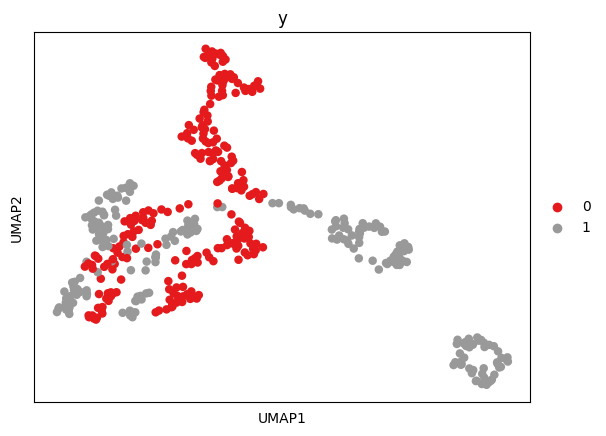

In [38]:
# Convert the 'y' column to the pandas 'category' dtype
adata_metacells.obs['y'] = adata_metacells.obs['y'].astype('category')
adata_metacells.obs['sample_id'] = adata_metacells.obs['sample_id'].astype('category')
# The plotting command will now work correctly
sc.pl.umap(adata_metacells, color='y', palette='Set1', s=150)

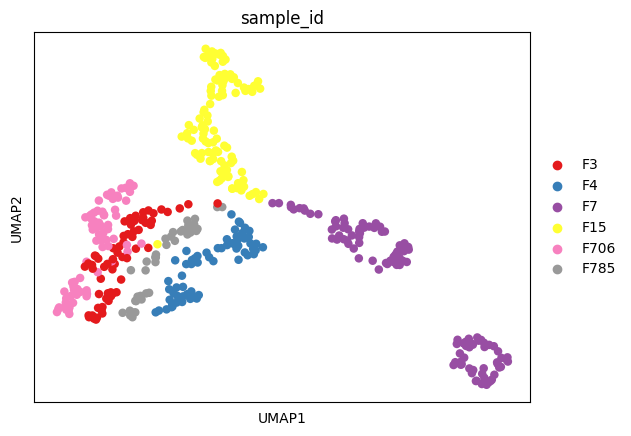

In [39]:
sc.pl.umap(adata_metacells, color='sample_id', palette='Set1', s=150)

### Overlay SEACell centroids on the single-cell UMAP

The exact dpeerlab recipe (`SEACells.plot.plot_2D` → `umap.groupby("SEACell").mean()`) needs the per-cell `SEACell` assignment CSVs that SeaShells emits per sample. Those live on Bridges-2 (`/ocean/...`) and aren't on `/ix`, so we approximate:

1. Load the single-cell `adata_subset` (Fast IIB/IIX, chosen sex) — it carries `X_pca_harmony` and `X_umap` from the parent harmony-corrected adata.
2. Load the aggregated metacell adata.
3. For each metacell, find its **k nearest single cells in log-normalized HVG expression** (k ≈ `cells_per_metacell` = 75, so neighbors should largely *be* its true members).
4. Average those cells' `X_umap` → metacell coordinate.
5. Scatter single cells in light grey, overlay metacells coloured by WT/KO.


In [3]:
# Step 1: load the single-cell adata and subset to Fast IIB/IIX of the chosen sex.
# Pick sex_to_plot = 'M' or 'F' to match the metacell run.
sex_to_plot = 'F'

adata = sc.read_h5ad(
    '/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/adata_type2_female_clean.h5ad'
)

adata_subset = adata[
    adata.obs['re_annot'].isin(['Fast IIB', 'Fast IIX', 'Fast IIA']) & (adata.obs['sex'] == sex_to_plot)
].copy()

# The harmony adata's .X is already log-normalized — only normalize if it looks raw.
if adata_subset.X.max() > 20:
    sc.pp.normalize_total(adata_subset, target_sum=1e4)
    sc.pp.log1p(adata_subset)

# Load the metacell adata for this sex
mc_path = f'/ix/djishnu/Akanksha/datasets/ERCC1_KO/objects/objects/seacells_{sex_to_plot}_FastIIB_FastIIX_harmonyv2.h5ad'
adata_mc = sc.read_h5ad(mc_path)
print(f'single cells: {adata_subset.n_obs}, metacells: {adata_mc.n_obs}')
print('gene-space identical:', list(adata_subset.var_names) == list(adata_mc.var_names))


single cells: 33681, metacells: 451
gene-space identical: True


In [4]:
# Step 2: PCA fit only. The single-cell UMAP background = inherited X_umap (UNCHANGED).
# All projection methods below map metacells -> positions on this fixed background.
import numpy as np
import scipy.sparse as sp
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

shared = adata_subset.var_names.intersection(adata_mc.var_names)
X_sc = adata_subset[:, shared].X
X_mc = adata_mc[:, shared].X
if sp.issparse(X_sc): X_sc = X_sc.toarray()
if sp.issparse(X_mc): X_mc = X_mc.toarray()

# Shared PCA so metacells live in the same 50d space as single cells
pca = PCA(n_components=50, random_state=0)
X_sc_pca = pca.fit_transform(X_sc)
X_mc_pca = pca.transform(X_mc)
print(f'PCA var explained: {pca.explained_variance_ratio_.sum():.3f}')

umap_sc = adata_subset.obsm['X_umap']   # INHERITED — never modified


def project_metacells(k, weighting='uniform', feature_space='pca'):
    """k-NN project metacells -> position on inherited X_umap.

    feature_space: 'pca' (recommended) or 'hvg' (raw 3000-gene log-norm).
    weighting:     'uniform' or 'gaussian'.
    """
    X_ref = X_sc_pca if feature_space == 'pca' else X_sc
    X_qry = X_mc_pca if feature_space == 'pca' else X_mc
    metric = 'euclidean' if feature_space == 'pca' else 'cosine'
    nn = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1).fit(X_ref)
    dists, idx = nn.kneighbors(X_qry)
    if weighting == 'gaussian':
        sigma = max(np.median(dists), 1e-6)
        w = np.exp(-(dists ** 2) / (2 * sigma ** 2)); w /= w.sum(axis=1, keepdims=True)
    else:
        w = np.full_like(dists, 1.0 / k)
    return np.einsum('mk,mkd->md', w, umap_sc[idx])


PCA var explained: 0.278


method                  spread  hull_cov  silhou  composite
----------------------------------------------------------------
k=1  PCA                 0.962     0.473  -0.000      0.674
k=5  PCA                 0.927     0.419  -0.001      0.639
k=15 PCA uniform         0.912     0.418  -0.000      0.632
k=15 PCA gaussian        0.913     0.419  -0.000      0.633
k=75 PCA (orig)          0.888     0.386   0.000      0.610
k=1  HVG cosine          0.806     0.238   0.014      0.519

best by composite: k=1  PCA


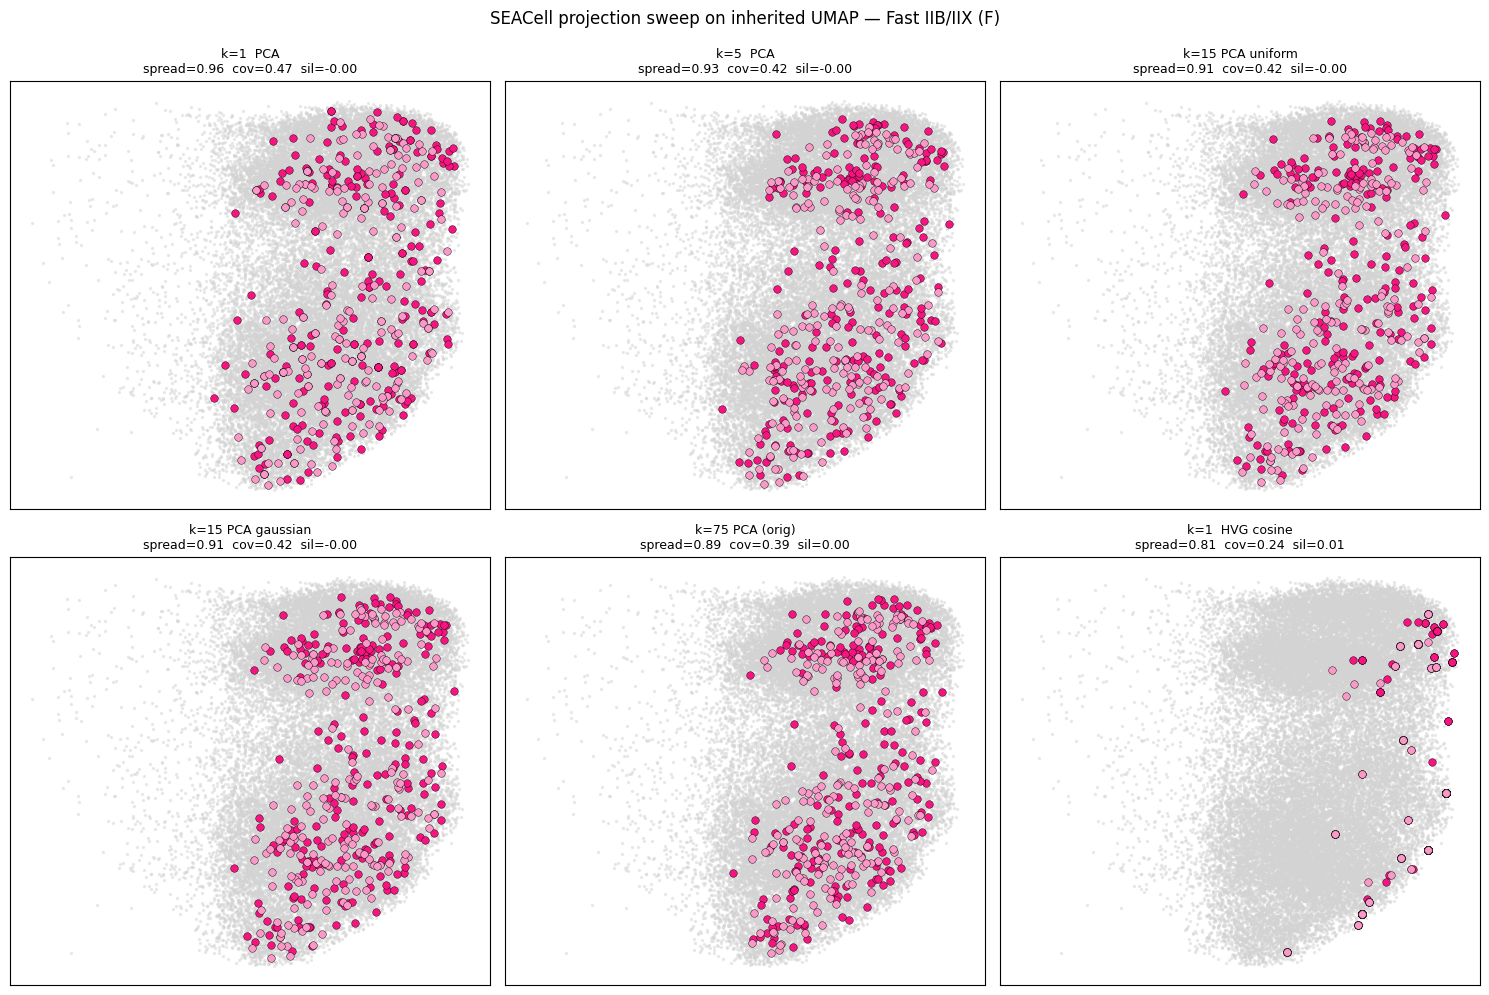

In [5]:
# Step 2b: hyperparameter sweep against the FIXED inherited UMAP background.
# Metrics (higher = better on first three; composite auto-picks):
#   - spread_ratio : std(metacells) / std(single cells)   [1.0 = matched spread]
#   - hull_coverage: hull(metacells) / hull(single cells) [1.0 = full coverage]
#   - silhouette   : WT vs KO separation among metacells in projected space
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from scipy.spatial import ConvexHull

cond_label = adata_mc.obs['y'].map({0: 'WT', 1: 'KO'}).values if adata_mc.obs['y'].dtype.kind in 'iu' \
    else adata_mc.obs['y'].astype(str).map({'0': 'WT', '1': 'KO'}).values

def _scores(coords):
    sr  = float((coords.std(axis=0) / umap_sc.std(axis=0)).mean())
    sil = float(silhouette_score(coords, cond_label)) if len(set(cond_label)) > 1 else float('nan')
    try:
        cov = ConvexHull(coords).volume / ConvexHull(umap_sc).volume
    except Exception:
        cov = float('nan')
    comp = 0.4 * sr + 0.4 * cov + 0.2 * max(sil + 1, 0) / 2
    return sr, cov, sil, comp

methods = {
    'k=1  PCA':              project_metacells(1),
    'k=5  PCA':              project_metacells(5),
    'k=15 PCA uniform':      project_metacells(15),
    'k=15 PCA gaussian':     project_metacells(15, 'gaussian'),
    'k=75 PCA (orig)':       project_metacells(75),
    'k=1  HVG cosine':       project_metacells(1, feature_space='hvg'),
}

print(f'{"method":22s}  spread  hull_cov  silhou  composite')
print('-' * 64)
scores = {}
for name, coords in methods.items():
    sr, cov, sil, comp = _scores(coords)
    scores[name] = comp
    print(f'{name:22s}  {sr:6.3f}  {cov:8.3f}  {sil:6.3f}  {comp:9.3f}')
best = max(scores, key=scores.get)
print(f'\nbest by composite: {best}')

# Visual sweep — single-cell UMAP background is identical in every panel
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey=True)
for ax, (name, coords) in zip(axes.ravel(), methods.items()):
    ax.scatter(umap_sc[:, 0], umap_sc[:, 1], s=2, color='lightgrey', alpha=0.4, rasterized=True)
    for cond in ['WT', 'KO']:
        sel = cond_label == cond
        ax.scatter(coords[sel, 0], coords[sel, 1],
                   s=30, c=SEX_CONDITION_PALETTE[(sex_to_plot, cond)],
                   edgecolor='black', linewidth=0.3)
    sr, cov, sil, comp = _scores(coords)
    ax.set_title(f'{name}\nspread={sr:.2f}  cov={cov:.2f}  sil={sil:.2f}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'SEACell projection sweep on inherited UMAP — Fast IIB/IIX ({sex_to_plot})', y=0.99)
plt.tight_layout(); plt.show()


saved: /ix/djishnu/Akanksha/datasets/ERCC1_KO/figures/seacells_projected_umap_FastIIB_IIX_F_k=75_PCA_orig.svg


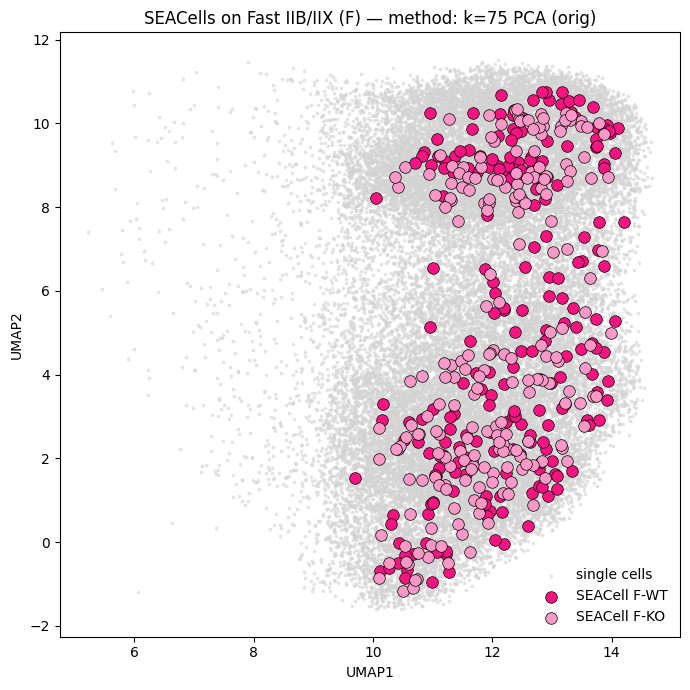

In [7]:
# Step 3: final plot on the INHERITED UMAP (grey cells unchanged from the parent adata).
# Set chosen_method to any key from `methods` in the sweep; defaults to the composite winner.
import os
import matplotlib.pyplot as plt

#chosen_method = best   # e.g. override to 'k=1  PCA' for max spread, or 'k=5  PCA' for less noise
chosen_method = 'k=75 PCA (orig)'
mc_umap = methods[chosen_method]
adata_mc.obsm['X_umap_projected'] = mc_umap

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(umap_sc[:, 0], umap_sc[:, 1],
           s=3, color='lightgrey', alpha=0.5, rasterized=True, label='single cells')
for cond in ['WT', 'KO']:
    color = SEX_CONDITION_PALETTE[(sex_to_plot, cond)]
    sel = cond_label == cond
    ax.scatter(mc_umap[sel, 0], mc_umap[sel, 1],
               s=70, c=color, edgecolor='black', linewidth=0.5,
               label=f'SEACell {sex_to_plot}-{cond}')
ax.set_xlabel('UMAP1'); ax.set_ylabel('UMAP2')
ax.set_title(f'SEACells on Fast IIB/IIX ({sex_to_plot}) — method: {chosen_method}')
ax.legend(loc='best', frameon=False)
plt.tight_layout()

# Save as SVG with editable text (svg.fonttype='none' set in cell 2 keeps text as text).
method_slug = chosen_method.replace(' ', '_').replace('(', '').replace(')', '')
svg_path = os.path.join(
    figures_dir,
    f'seacells_projected_umap_FastIIB_IIX_{sex_to_plot}_{method_slug}.svg'
)
fig.savefig(svg_path, **figure_params)
print(f'saved: {svg_path}')

plt.show()


## check expression of certain genes

In [3]:
# load adata
adata = sc.read_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad')

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [41]:
adata

AnnData object with n_obs × n_vars = 86672 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid', '_scvi_uui

In [5]:
adata.obs

,sample_id,cell_type,condition,background_fraction,cell_probability,cell_size,droplet_efficiency,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,...,pct_counts_ribo_cb,total_counts_hb_cb,log1p_total_counts_hb_cb,pct_counts_hb_cb,n_genes,sex,batch,_scvi_batch,_scvi_labels,C_scANVI
AAACCCAAGATTCGAA-1,F7_KO,Fast IIX,KO,0.031034,0.999955,4220.201172,1.249208,1798,7.494986,4214,...,0.0,0,0.0,0.0,1798,F,2024,0,3,Fast IIX
AAACCCACACTCATAG-1,F7_KO,Fast IIB,KO,0.038591,0.998573,3995.092041,1.000975,1400,7.244942,3139,...,0.0,0,0.0,0.0,1400,F,2024,0,2,Fast IIB
AAACCCACAGCCTTCT-1,F7_KO,Fast IIX,KO,0.020231,0.999955,5067.773438,1.299482,2042,7.622175,5519,...,0.0,0,0.0,0.0,2042,F,2024,0,3,Fast IIX
AAACCCACAGTATGAA-1,F7_KO,Fast IIX,KO,0.025974,0.999955,4462.444336,1.488916,2029,7.615791,5397,...,0.0,0,0.0,0.0,2029,F,2024,0,3,Fast IIX
AAACCCACATCATTGG-1,F7_KO,Fast IIX,KO,0.119454,0.999957,3054.103760,0.886010,998,6.906755,1806,...,0.0,0,0.0,0.0,998,F,2024,0,3,Fast IIX
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGCCCTCATATCCC-1,M6_WT,Unknown,WT,0.260239,0.999354,2003.506958,0.802182,535,6.284134,867,...,0.0,0,0.0,0.0,535,M,2025,1,10,Fast IIX
TGTGCCCTCCACCTGC-1,M6_WT,Unknown,WT,0.228600,0.999950,2426.421387,1.073309,751,6.622736,1559,...,0.0,0,0.0,0.0,751,M,2025,1,10,Pericyte
TGTGCCCTCCTCTCTC-1,M6_WT,Unknown,WT,0.148233,0.999252,2246.069580,1.030120,897,6.800170,1494,...,0.0,0,0.0,0.0,897,M,2025,1,10,EC
TGTGCCCTCGTCTCGC-1,M6_WT,Unknown,WT,0.108752,0.999906,2318.659424,1.087894,906,6.810142,1721,...,0.0,0,0.0,0.0,906,M,2025,1,10,Fast IIB


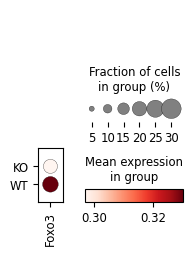

In [42]:
sc.pl.dotplot(adata, 'Foxo3', groupby='condition')

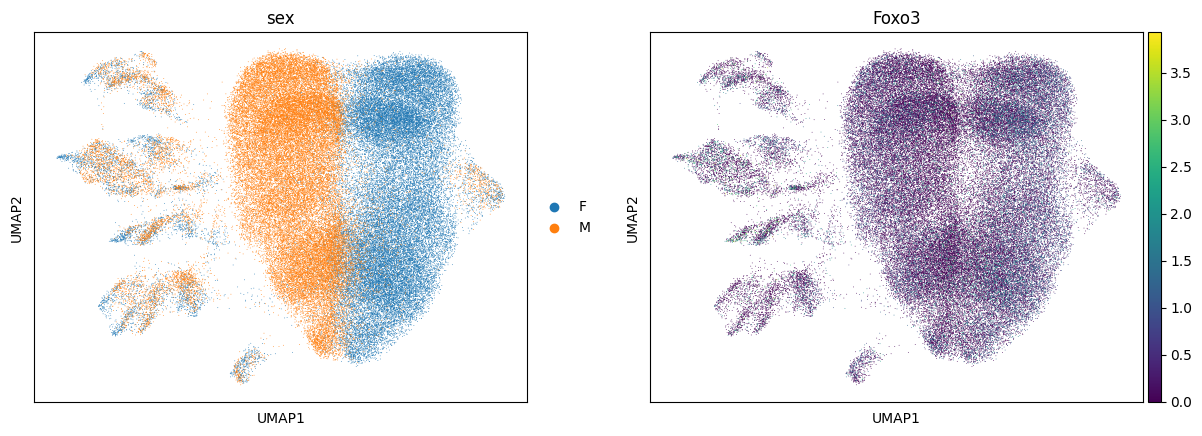

In [ ]:
sc.pl.umap(adata, color=['sex', 'Foxo3'])